### Import Libraries and Configure Environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

### Load Dataset

In [4]:
df = pd.read_csv('../data/HAM10000_metadata.csv')
print('Shape:', df.shape)
df.head()

Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### Dataset Overview and Missing Values Analysis

In [ ]:
print('dtypes')
print(df.dtypes)
print()

dtypes
lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
dtype: object



In [ ]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'pct%': missing_pct})[missing > 0])
print()


=== Missing Values ===
     count  pct%
age     57  0.57



In [ ]:
print('=== Unique Values per Column ===')
print(df.nunique())
print()

=== Unique Values per Column ===
lesion_id        7470
image_id        10015
dx                  7
dx_type             4
age                18
sex                 3
localization       15
dtype: int64



In [ ]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


### Target Variable Analysis (Diagnosis Classes)

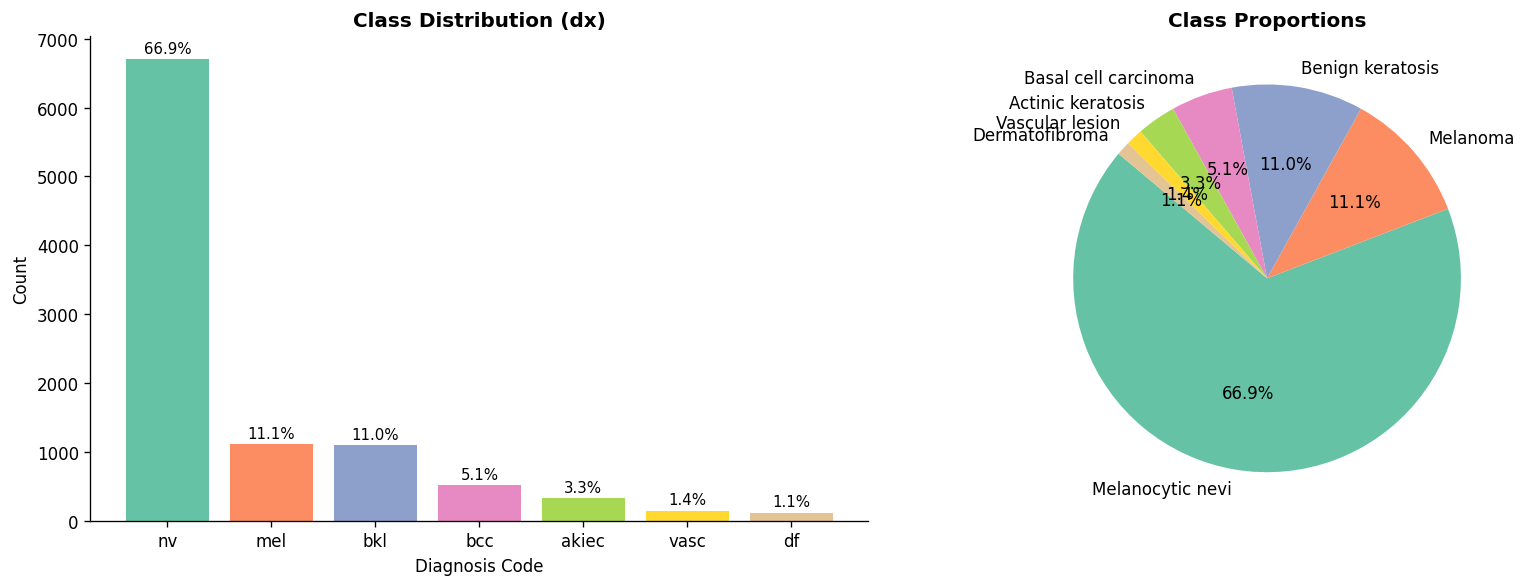


Imbalance ratio (majority/minority): 58.3x
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
label_map = {
    'nv':   'Melanocytic nevi',
    'mel':  'Melanoma',
    'bkl':  'Benign keratosis',
    'bcc':  'Basal cell carcinoma',
    'akiec':'Actinic keratosis',
    'vasc': 'Vascular lesion',
    'df':   'Dermatofibroma'
}

counts = df['dx'].value_counts()
pcts   = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(counts.index, counts.values,
                   color=sns.color_palette('Set2', len(counts)))
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Class Distribution (dx)', fontweight='bold')
axes[0].set_xlabel('Diagnosis Code')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values,
            labels=[label_map.get(k, k) for k in counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(counts)))
axes[1].set_title('Class Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nImbalance ratio (majority/minority): {counts.max()/counts.min():.1f}x')
print(counts)

### Age Distribution Analysis

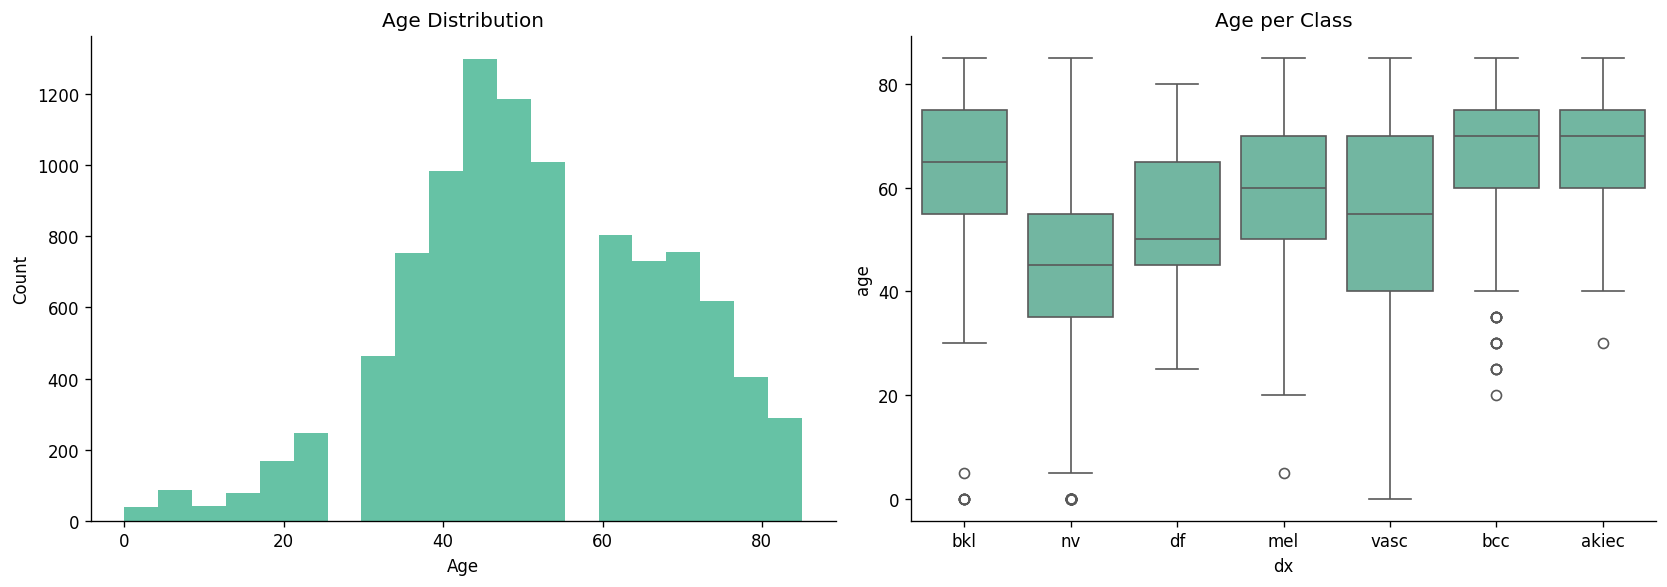

        count  mean   std   min   25%   50%   75%   max
dx                                                     
akiec   327.0  66.5  11.5  30.0  60.0  70.0  75.0  85.0
bcc     514.0  66.8  13.7  20.0  60.0  70.0  75.0  85.0
bkl    1089.0  64.3  14.1   0.0  55.0  65.0  75.0  85.0
df      115.0  53.0  13.6  25.0  45.0  50.0  65.0  80.0
mel    1111.0  60.7  15.2   5.0  50.0  60.0  70.0  85.0
nv     6660.0  46.5  15.2   0.0  35.0  45.0  55.0  85.0
vasc    142.0  51.4  21.6   0.0  40.0  55.0  70.0  85.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['age'].dropna(), bins=20)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='dx', y='age', ax=axes[1])
axes[1].set_title('Age per Class')

plt.tight_layout()
plt.show()

print(df.groupby('dx')['age'].describe().round(1))

### Age Outlier Detection Using IQR

IQR fence  : [2.5, 102.5]
Outliers   : 39


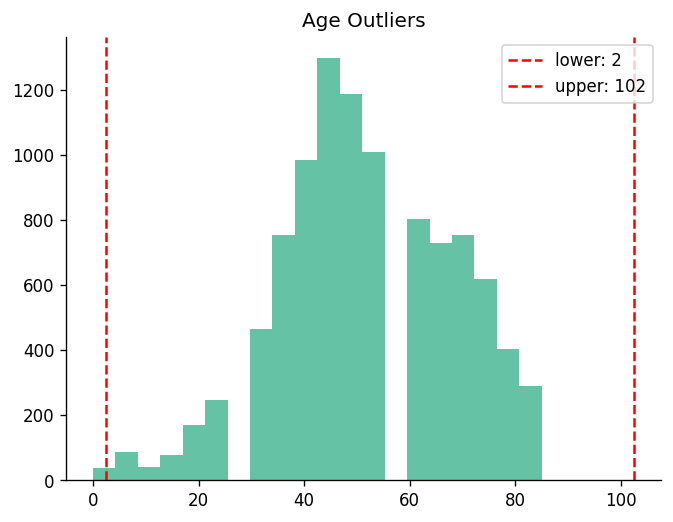

In [ ]:
Q1, Q3 = df['age'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]
print(f'IQR fence  : [{lower:.1f}, {upper:.1f}]')
print(f'Outliers   : {len(outliers)}')

plt.hist(df['age'].dropna(), bins=20)
plt.axvline(lower, color='red', linestyle='--', label=f'lower: {lower:.0f}')
plt.axvline(upper, color='red', linestyle='--', label=f'upper: {upper:.0f}')
plt.title('Age Outliers')
plt.legend()
plt.show()

### Age Density Distribution by Diagnosis Class

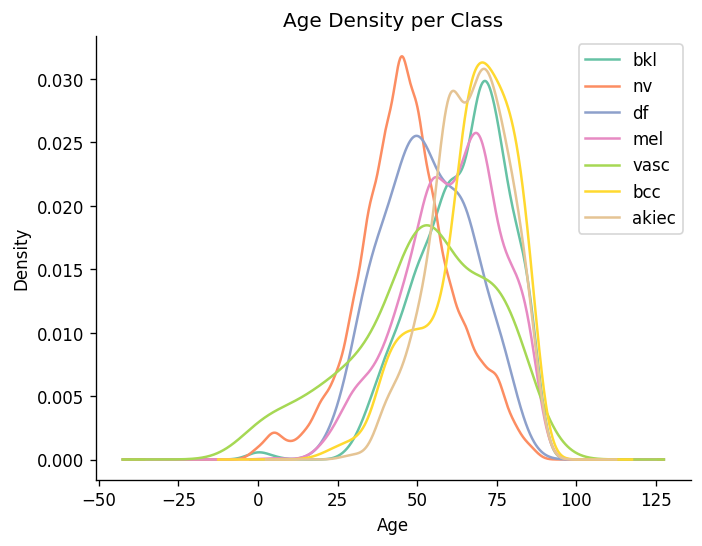

In [ ]:
for cls in df['dx'].unique():
    df[df['dx'] == cls]['age'].dropna().plot.kde(label=cls)

plt.title('Age Density per Class')
plt.xlabel('Age')
plt.legend()
plt.show()

### Gender Distribution Analysis

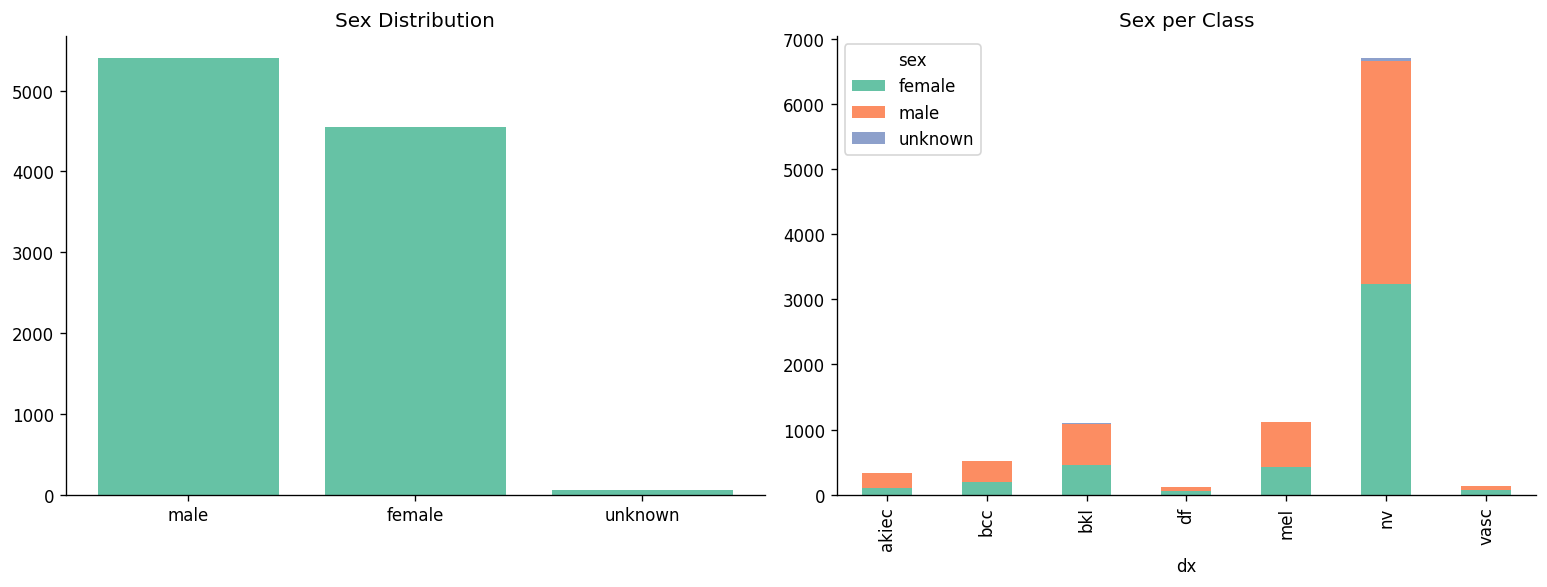

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sex_counts = df['sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values)
axes[0].set_title('Sex Distribution')

sex_dx = df.groupby(['dx', 'sex']).size().unstack(fill_value=0)
sex_dx.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Sex per Class')

plt.tight_layout()
plt.show()

### Lesion Localization Analysis

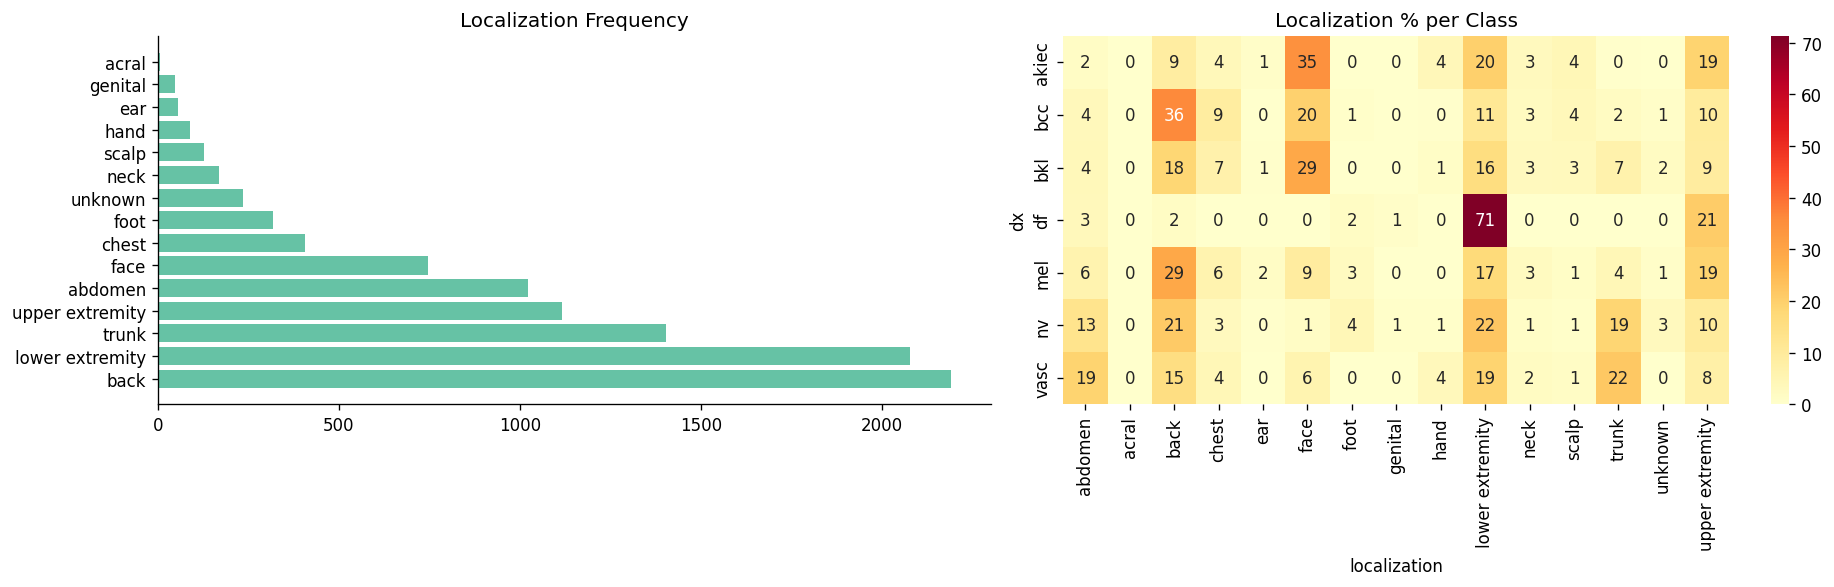

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

loc_counts = df['localization'].value_counts()
axes[0].barh(loc_counts.index, loc_counts.values)
axes[0].set_title('Localization Frequency')

heatmap_data = pd.crosstab(df['dx'], df['localization'], normalize='index') * 100
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Localization % per Class')

plt.tight_layout()
plt.show()

### Diagnosis Method Analysis

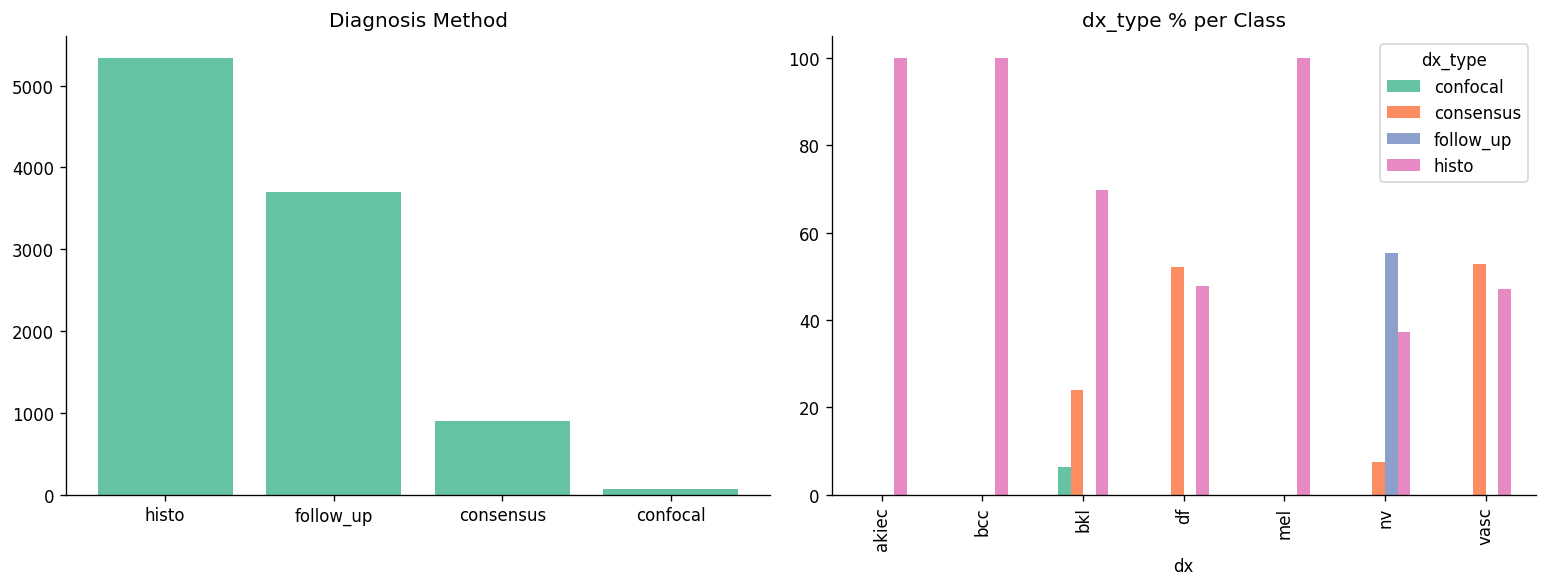

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dxt = df['dx_type'].value_counts()
axes[0].bar(dxt.index, dxt.values)
axes[0].set_title('Diagnosis Method')

dxt_dx = pd.crosstab(df['dx'], df['dx_type'], normalize='index') * 100
dxt_dx.plot(kind='bar', ax=axes[1])
axes[1].set_title('dx_type % per Class')

plt.tight_layout()
plt.show()

### Correlation Matrix Analysis

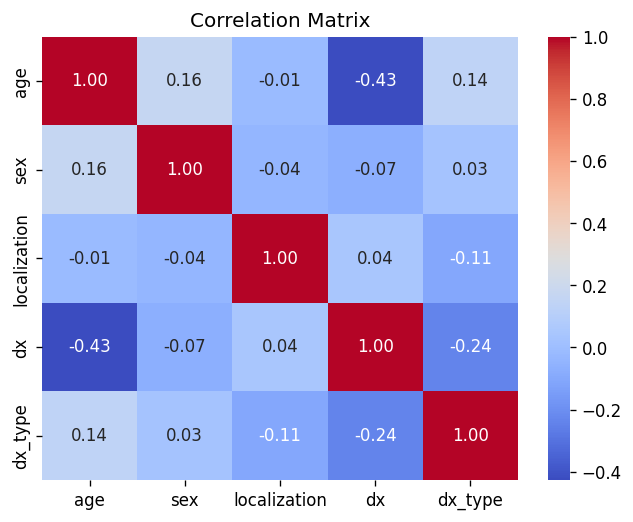

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_enc = df[['age', 'sex', 'localization', 'dx', 'dx_type']].copy()

for col in ['sex', 'localization', 'dx', 'dx_type']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

df_enc['age'] = df_enc['age'].fillna(df_enc['age'].mean())

sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Checking Repeated Lesions

In [ ]:
dup = df[df.duplicated('lesion_id', keep=False)]
print(f'Rows with duplicate lesion_id: {len(dup)}')

imgs_per_lesion = df.groupby('lesion_id')['image_id'].count()
print(imgs_per_lesion.value_counts().rename('# lesions'))

Rows with duplicate lesion_id: 4501
image_id
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: # lesions, dtype: int64


### Dataset Quality Summary

In [ ]:
print(f'Total rows     : {len(df)}')
print(f'Unique lesions : {df["lesion_id"].nunique()}')
print(f'Missing age    : {df["age"].isnull().sum()}')
print(f'Missing sex    : {df["sex"].isnull().sum()}')
print(f'Imbalance ratio: {df["dx"].value_counts().max() / df["dx"].value_counts().min():.1f}x')
print(df['dx'].value_counts())

Total rows     : 10015
Unique lesions : 7470
Missing age    : 57
Missing sex    : 0
Imbalance ratio: 58.3x
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
